In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
df_store = pd.read_csv('/content/drive/MyDrive//idAI/dataset/store5.csv')
df_store.head()

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,1452,2013-01-01,5,AUTOMOTIVE,0.0,0,NaN
1,1453,2013-01-01,5,BABY CARE,0.0,0,NaN
2,1454,2013-01-01,5,BEAUTY,0.0,0,NaN
3,1455,2013-01-01,5,BEVERAGES,0.0,0,NaN
4,1456,2013-01-01,5,BOOKS,0.0,0,NaN


In [16]:
output_path = '/content/drive/MyDrive//idAI/dataset/store5.xlsx'
df_store.to_excel(output_path, index=False)

print(f"File converted and saved to: {output_path}")

File converted and saved to: /content/drive/MyDrive//idAI/dataset/store5.xlsx


In [17]:
def top_3_sales(df_store):
    family_sales = df_store.groupby('family')['sales'].sum().sort_values(ascending=False)

    return family_sales.head(3)

result = top_3_sales(df_store)
print(top_3_sales(df_store))

family
GROCERY I    5262681.658
BEVERAGES    2533831.000
CLEANING     1667748.000
Name: sales, dtype: float64


In [18]:
df_store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55572 entries, 0 to 55571
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           55572 non-null  int64  
 1   date         55572 non-null  object 
 2   store_nbr    55572 non-null  int64  
 3   family       55572 non-null  object 
 4   sales        55572 non-null  float64
 5   onpromotion  55572 non-null  int64  
 6   dcoilwtico   38379 non-null  float64
dtypes: float64(2), int64(3), object(2)
memory usage: 3.0+ MB


In [19]:
df_store.isnull().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0
dcoilwtico,17193


In [20]:
df_store['date'] = pd.to_datetime(df_store['date']) #mengubah tipe data di kolom date dari object, menjadi datetime

In [21]:
df_store['date'] = pd.to_datetime(df_store['date'])

numeric_cols = ['sales', 'onpromotion', 'dcoilwtico']
data_num = df_store[numeric_cols].dropna()

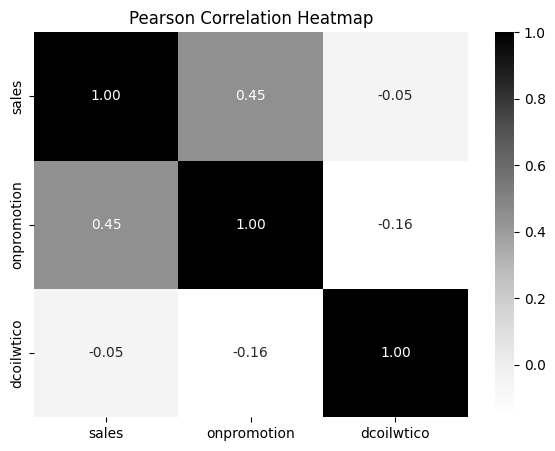

In [25]:
correlation_matrix = data_num.corr(method='pearson')

plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='Greys', fmt='.2f')
plt.title('Pearson Correlation Heatmap')
plt.show()